# OnTime — Model Comparison Notebook
**Target:** `avg_delay_seconds` (regression)

We load all weekly parquet files, engineer features, train multiple regression models, and compare them side-by-side so the best model can be selected for the `ml_service` API.

### Models evaluated
| # | Model | Why                                                        |
|---|-------|------------------------------------------------------------|
| 1 | Linear Regression | Fast baseline — shows if the problem is linearly separable |
| 2 | Ridge Regression | Baseline + L2 regularization                               |
| 3 | Random Forest | Handles non-linearity & categorical interactions well      |
| 4 | Gradient Boosting (XGBoost-style via sklearn) | Usually best on tabular data                               |
| 5 | LightGBM | Fast alternative to GBM, good with categoricals            |

> **Note on `holiday` column:** Currently all values are `'no'` because the aggregated weekly format makes individual holiday flagging unreliable. We will replace the column if/when it is fixed.

In [2]:
# %pip install -r ../requirements.txt 
%pip install matplotlib seaborn

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pillow-12.2.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pandas-3.0.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.

After installing packages, restart the notebook kernel once so the updated NumPy/Matplotlib binaries are loaded.

## Imports & Config

In [3]:
import sys
print(sys.executable)
# %pip install numpy


/Users/edwardkang/Desktop/Senior Design/.venv/bin/python


In [4]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import joblib
import json

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style='whitegrid', palette='muted')

# ── CONFIG ─────────────────────────────────────────────────────────────────
DATA_DIR   = '../data/final_data_updated'            # folder containing all weekly parquet/csv files
FILE_EXT   = 'parquet'                               # change to 'csv' if using csv files
TARGET_COL = 'avg_delay_seconds'
TEST_SIZE  = 0.2
RANDOM_STATE = 42
# ───────────────────────────────────────────────────────────────────────────

print('Libraries loaded ✓')
print(f'DATA_DIR resolved to: {os.path.abspath(DATA_DIR)}')

Libraries loaded ✓
DATA_DIR resolved to: /Users/edwardkang/Desktop/Senior Design/ml_service/data/final_data_updated


## Load All Files

In [5]:
def load_all_files(data_dir: str, ext: str = 'parquet') -> pd.DataFrame:
    """Load all weekly files from data_dir into one DataFrame."""
    pattern = os.path.join(data_dir, f'*.{ext}')
    files = sorted(glob.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No .{ext} files found in {data_dir}")
    
    frames = []
    for f in files:
        df = pd.read_parquet(f)

        # derive the source filename so we can debug later
        df['_source_file'] = os.path.basename(f)
        frames.append(df)
    
    combined = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(files)} files → {combined.shape[0]:,} rows × {combined.shape[1]} cols")
    return combined

df_raw = load_all_files(DATA_DIR, FILE_EXT)
df_raw.head(3)

Loaded 86 files → 2,988,763 rows × 13 cols


,month_period,day_of_week,route_name,direction,stop_id,stop_name,stop_sequence,hour,avg_delay_seconds,count,season,holiday,_source_file
0,2024-12,Tuesday,1,Downtown/South,103S,238 St,2.0,23.0,-38.714286,7,Winter,no,2024-12_Tuesday.parquet
1,2024-12,Tuesday,1,Downtown/South,104S,231 St,3.0,23.0,-33.571429,7,Winter,no,2024-12_Tuesday.parquet
2,2024-12,Tuesday,1,Downtown/South,106S,Marble Hill-225 St,4.0,23.0,-39.142857,7,Winter,no,2024-12_Tuesday.parquet


## Exploratory Data Analysis

In [6]:
print("=== Schema ===")
print(df_raw.dtypes)
print(f"\n=== Nulls ===")
print(df_raw.isnull().sum())
print(f"\n=== Target summary ===")
print(df_raw[TARGET_COL].describe())

=== Schema ===
month_period          object
day_of_week           object
route_name            object
direction             object
stop_id               object
stop_name             object
stop_sequence        float64
hour                 float64
avg_delay_seconds    float64
count                  int64
season                object
holiday               object
_source_file          object
dtype: object

=== Nulls ===
month_period         0
day_of_week          0
route_name           0
direction            0
stop_id              0
stop_name            0
stop_sequence        0
hour                 0
avg_delay_seconds    0
count                0
season               0
holiday              0
_source_file         0
dtype: int64

=== Target summary ===
count    2.988763e+06
mean     1.356207e+01
std      6.660067e+01
min     -7.035000e+02
25%     -1.971053e+01
50%      5.965517e+00
75%      3.953333e+01
max      7.177500e+02
Name: avg_delay_seconds, dtype: float64


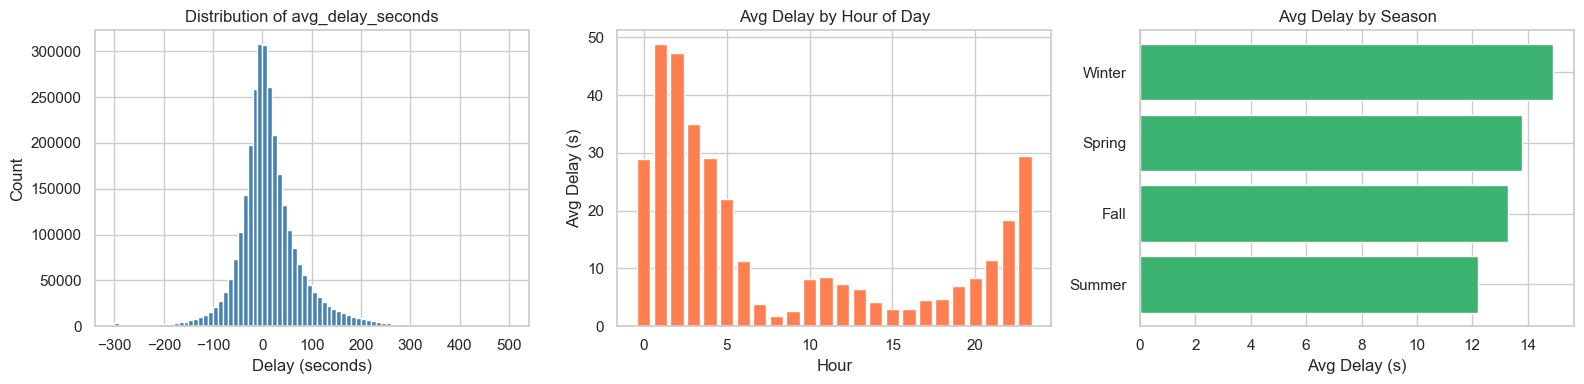

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution of target
axes[0].hist(df_raw[TARGET_COL].clip(-300, 500), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution of avg_delay_seconds")
axes[0].set_xlabel("Delay (seconds)")
axes[0].set_ylabel("Count")

# Delay by hour
hour_means = df_raw.groupby('hour')[TARGET_COL].mean().sort_index()
axes[1].bar(hour_means.index, hour_means.values, color='coral')
axes[1].set_title("Avg Delay by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Avg Delay (s)")

# Delay by season
season_means = df_raw.groupby('season')[TARGET_COL].mean().sort_values()
axes[2].barh(season_means.index, season_means.values, color='mediumseagreen')
axes[2].set_title("Avg Delay by Season")
axes[2].set_xlabel("Avg Delay (s)")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Delay by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_means = df_raw.groupby('day_of_week')[TARGET_COL].mean().reindex(
    [d for d in dow_order if d in df_raw['day_of_week'].unique()]
)
axes[0].bar(dow_means.index, dow_means.values, color='mediumpurple')
axes[0].set_title("Avg Delay by Day of Week")
axes[0].set_ylabel("Avg Delay (s)")
axes[0].tick_params(axis='x', rotation=30)

# Delay by route
route_means = df_raw.groupby('route_name')[TARGET_COL].mean().sort_values(ascending=False).head(20)
axes[1].barh(route_means.index, route_means.values, color='goldenrod')
axes[1].set_title("Avg Delay by Route (Top 20)")
axes[1].set_xlabel("Avg Delay (s)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [8]:
def engineer_features(df: pd.DataFrame, encoders: dict = None) -> tuple:
    """
    Engineer features. If encoders is None, fit new LabelEncoders on df (training data).
    Otherwise apply the provided encoders without refitting (test data).
    Returns (df_engineered, encoders).
    """
    df = df.copy()

    # Separate month_period into year and month columns
    if 'month_period' in df.columns:
        df['year']  = df['month_period'].str[:4].astype(int)
        df['month'] = df['month_period'].str[5:7].astype(int)

    # Cyclical encoding for hour (captures 23→0 wrap-around)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # Cyclical encoding for month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Rush-hour and late-night flags
    df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)
    df['is_late_night'] = df['hour'].isin([0, 1, 2, 3, 4]).astype(int)

    # Label-encode categoricals 
    cat_cols = ['route_name', 'direction', 'stop_id', 'day_of_week', 'season']
    fitted_encoders = {}
    for col in cat_cols:
        if col in df.columns:
            if encoders is None:
                le = LabelEncoder()
                df[col + '_enc'] = le.fit_transform(df[col].astype(str))
                fitted_encoders[col] = le
            else:
                le = encoders[col]
                # Map unseen labels to 0 instead of raising an error
                known = set(le.classes_)
                df[col + '_enc'] = df[col].astype(str).map(
                    lambda v, le=le: le.transform([v])[0] if v in known else 0
                )

    # Drop columns not used as features
    drop_cols = [
        'month_period', 'stop_name', 'holiday',
        'route_name', 'direction', 'stop_id',
        'day_of_week', 'season',
        '_source_file'
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df, (fitted_encoders if encoders is None else encoders)


## Train / Test Split

In [9]:
# Split raw data 
df_raw_clean = df_raw.dropna(subset=[TARGET_COL])
train_raw, test_raw = train_test_split(df_raw_clean, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Fit encoders on train only
df_train, encoders = engineer_features(train_raw)
df_test,  _        = engineer_features(test_raw, encoders=encoders)

X_train = df_train.drop(columns=[TARGET_COL])
y_train = df_train[TARGET_COL]
X_test  = df_test.drop(columns=[TARGET_COL])
y_test  = df_test[TARGET_COL]

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Features ({X_train.shape[1]}): {X_train.columns.tolist()}")

Train: 2,391,010 rows | Test: 597,753 rows
Features (16): ['stop_sequence', 'hour', 'count', 'year', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_rush_hour', 'is_late_night', 'route_name_enc', 'direction_enc', 'stop_id_enc', 'day_of_week_enc', 'season_enc']


## Model Definitions

In [10]:
# Other models commented out while tuning LightGBM — uncomment to compare again.
models = {
    # 'Linear Regression': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('model', LinearRegression())
    # ]),
    # 'Ridge (α=10)': Pipeline([
    #     ('scaler', StandardScaler()),
    #     ('model', Ridge(alpha=10))
    # ]),
    # 'Random Forest': RandomForestRegressor(
    #     n_estimators=200,
    #     max_depth=12,
    #     min_samples_leaf=5,
    #     n_jobs=-1,
    #     random_state=RANDOM_STATE
    # ),
    # 'Gradient Boosting': GradientBoostingRegressor(
    #     n_estimators=300,
    #     learning_rate=0.05,
    #     max_depth=5,
    #     subsample=0.8,
    #     random_state=RANDOM_STATE
    # ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=8000,
        learning_rate=0.03,
        num_leaves=127,
        max_depth=12,
        min_child_samples=80,
        subsample=0.85,
        subsample_freq=1,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        force_row_wise=True,
        verbose=-1,
    )
}

print(f"\nModels to evaluate: {list(models.keys())}")


Models to evaluate: ['LightGBM']


## Training & Evaluation

In [11]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Fit and return a dict of metrics."""
    print(f'  Training {name}...', end=' ')
    if isinstance(model, lgb.LGBMRegressor):
        # Holdout from train for early stopping (avoid tuning on the test set).
        X_fit, X_val, y_fit, y_val = train_test_split(
            X_train, y_train, test_size=0.1, random_state=RANDOM_STATE
        )
        model.fit(
            X_fit, y_fit,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
        )
    else:
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    # Mean Absolute Percentage Error (ignore near-zero targets)
    mask = np.abs(y_test) > 5
    mape = np.mean(np.abs((y_test[mask] - preds[mask]) / y_test[mask])) * 100
    
    print(f'MAE={mae:.1f}s  RMSE={rmse:.1f}s  R²={r2:.4f}')
    return {
        'Model': name,
        'MAE (s)': round(mae, 2),
        'RMSE (s)': round(rmse, 2),
        'R²': round(r2, 4),
        'MAPE (%)': round(mape, 2),
        '_model': model,
        '_preds': preds
    }

print('Training all models...\n')
results = [evaluate_model(name, m, X_train, X_test, y_train, y_test)
           for name, m in models.items()]

results_df = pd.DataFrame(results).drop(columns=['_model', '_preds'])
results_df = results_df.sort_values('MAE (s)')
print("\n=== Results Summary ===")
results_df

Training all models...

  Training LightGBM... MAE=29.6s  RMSE=43.6s  R²=0.5715

=== Results Summary ===


,Model,MAE (s),RMSE (s),R²,MAPE (%)
0,LightGBM,29.63,43.62,0.5715,89.03


## Visual Comparison

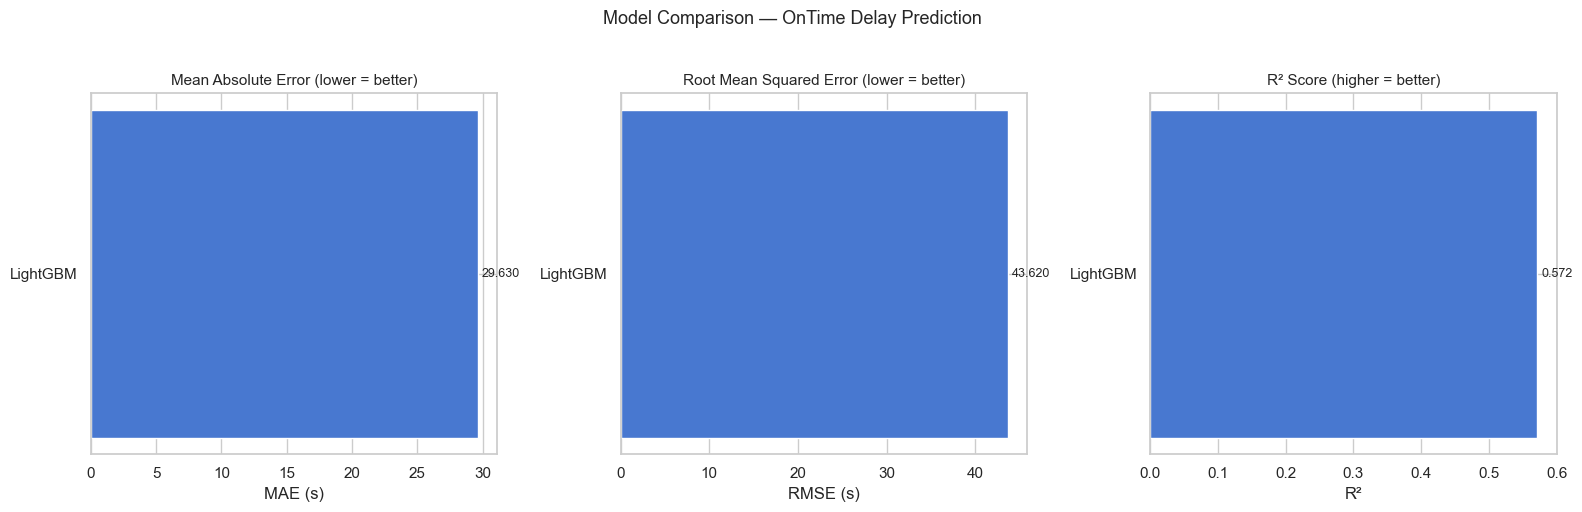

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = results_df['Model'].tolist()

colors = sns.color_palette('muted', len(model_names))

for ax, metric, title in zip(
    axes,
    ['MAE (s)', 'RMSE (s)', 'R²'],
    ['Mean Absolute Error (lower = better)',
     'Root Mean Squared Error (lower = better)',
     'R² Score (higher = better)']
):
    vals = results_df.set_index('Model')[metric].loc[model_names]
    bars = ax.barh(model_names, vals, color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — OnTime Delay Prediction', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

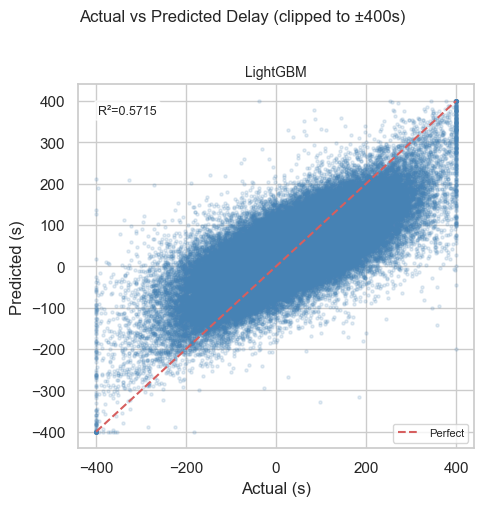

In [14]:
# Actual vs Predicted scatter for each model
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=True)
if n == 1: axes = [axes]

clip_val = 400
for ax, r in zip(axes, results):
    y_true_clipped = np.clip(y_test, -clip_val, clip_val)
    y_pred_clipped = np.clip(r['_preds'], -clip_val, clip_val)
    ax.scatter(y_true_clipped, y_pred_clipped, alpha=0.15, s=5, color='steelblue')
    ax.plot([-clip_val, clip_val], [-clip_val, clip_val], 'r--', lw=1.5, label='Perfect')
    ax.set_title(r['Model'], fontsize=10)
    ax.set_xlabel('Actual (s)')
    ax.set_ylabel('Predicted (s)')
    ax.legend(fontsize=8)
    ax.text(0.05, 0.92, f"R²={r['R²']}", transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Actual vs Predicted Delay (clipped to ±400s)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Feature Importances (Best Tree Model)

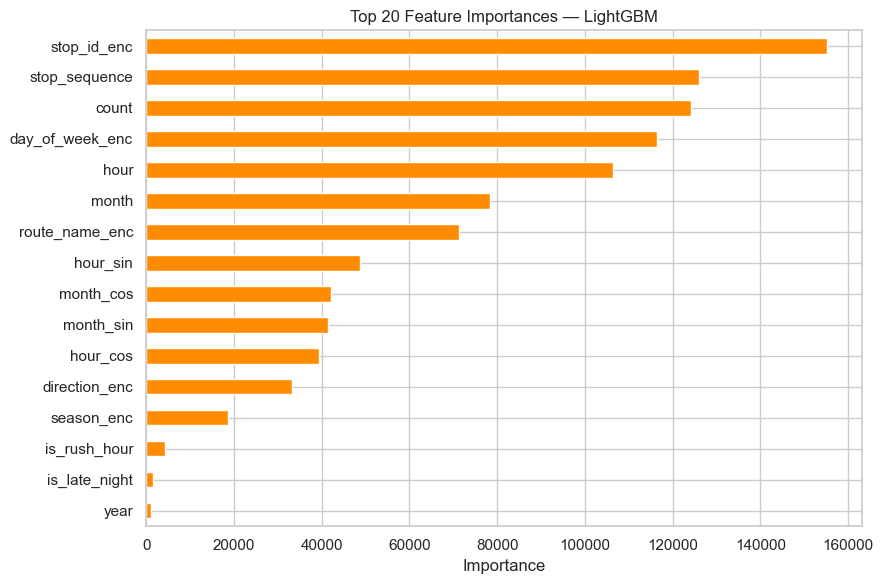

In [15]:
# Pick the best non-linear model to show feature importance
tree_model_names = ['LightGBM', 'Gradient Boosting', 'Random Forest']
best_tree = next(
    (r for r in sorted(results, key=lambda x: x['MAE (s)'])
     if r['Model'] in tree_model_names),
    None
)

if best_tree:
    model_obj = best_tree['_model']
    # Handle Pipeline wrapping
    estimator = model_obj.named_steps['model'] if hasattr(model_obj, 'named_steps') else model_obj
    importances = pd.Series(estimator.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=True).tail(20)

    plt.figure(figsize=(9, 6))
    importances.plot(kind='barh', color='darkorange')
    plt.title(f'Top 20 Feature Importances — {best_tree["Model"]}', fontsize=12)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('No tree model found for feature importances.')

## Residual Analysis (Best Model)

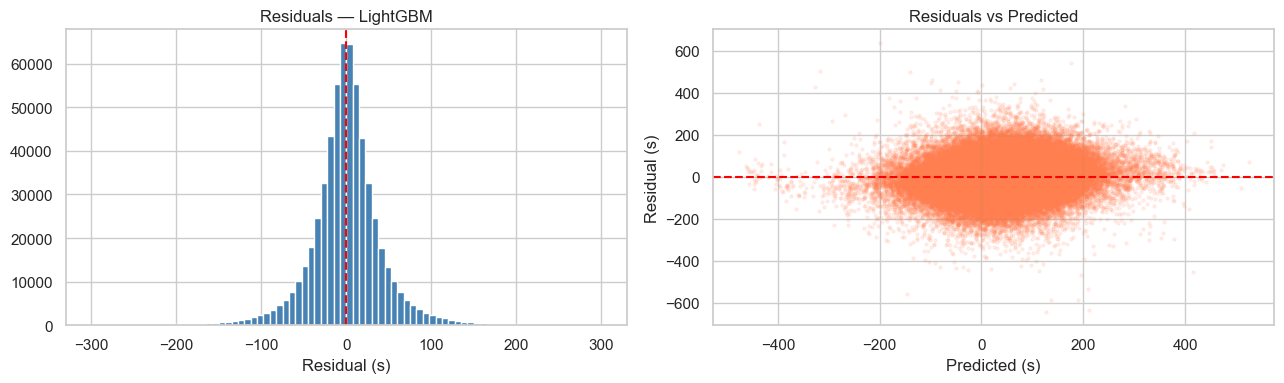


Best model: LightGBM
  MAE : 29.6 seconds
  RMSE: 43.6 seconds
  R²  : 0.5715


In [16]:
best = sorted(results, key=lambda x: x['MAE (s)'])[0]
residuals = y_test.values - best['_preds']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuals.clip(-300, 300), bins=80, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title(f'Residuals — {best["Model"]}')
axes[0].set_xlabel('Residual (s)')

axes[1].scatter(best['_preds'], residuals, alpha=0.1, s=5, color='coral')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted (s)')
axes[1].set_ylabel('Residual (s)')

plt.tight_layout()
plt.show()

print(f'\nBest model: {best["Model"]}')
print(f'  MAE : {best["MAE (s)"]:.1f} seconds')
print(f'  RMSE: {best["RMSE (s)"]:.1f} seconds')
print(f'  R²  : {best["R²"]}')

## Save Best Model

In [17]:
SAVE_DIR = '../models'
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_obj = best['_model']
model_path = os.path.join(SAVE_DIR, 'delay_model.joblib')
joblib.dump(best_model_obj, model_path)

# Save the fitted LabelEncoders so model.py can use the exact same mappings
encoders_path = os.path.join(SAVE_DIR, 'label_encoders.joblib')
joblib.dump(encoders, encoders_path)

# Save feature list and metrics metadata
feature_meta = {
    'model_name': best['Model'],
    'features': X_train.columns.tolist(),
    'target': TARGET_COL,
    'metrics': {
        'MAE_seconds': best['MAE (s)'],
        'RMSE_seconds': best['RMSE (s)'],
        'R2': best['R²'],
        'MAPE_pct': best['MAPE (%)']
    }
}
meta_path = os.path.join(SAVE_DIR, 'model_meta.json')
with open(meta_path, 'w') as f:
    json.dump(feature_meta, f, indent=2)

print(f'Model saved    → {os.path.abspath(model_path)}')
print(f'Encoders saved → {os.path.abspath(encoders_path)}')
print(f'Metadata saved → {os.path.abspath(meta_path)}')
print(json.dumps(feature_meta, indent=2))


Model saved    → /Users/edwardkang/Desktop/Senior Design/ml_service/models/delay_model.joblib
Encoders saved → /Users/edwardkang/Desktop/Senior Design/ml_service/models/label_encoders.joblib
Metadata saved → /Users/edwardkang/Desktop/Senior Design/ml_service/models/model_meta.json
{
  "model_name": "LightGBM",
  "features": [
    "stop_sequence",
    "hour",
    "count",
    "year",
    "month",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "is_rush_hour",
    "is_late_night",
    "route_name_enc",
    "direction_enc",
    "stop_id_enc",
    "day_of_week_enc",
    "season_enc"
  ],
  "target": "avg_delay_seconds",
  "metrics": {
    "MAE_seconds": 29.63,
    "RMSE_seconds": 43.62,
    "R2": 0.5715,
    "MAPE_pct": 89.03
  }
}


## API Contract Preview

Prediction endpoint:

```
POST /api/v1/predict
Content-Type: application/json

{
  "route_name": "7",
  "direction": "Downtown/South",
  "stop_id": "702S",
  "day_of_week": "Thursday",
  "hour": 8,
  "month": 3,
  "year": 2025,
  "stop_sequence": 2,
  "season": "Spring",
  "count": 12
}

→ Response:
{
  "predicted_delay_seconds": 45.3,
  "predicted_delay_minutes": 0.75,
  "model": "LightGBM"
}
```

> **Note:** `holiday` is excluded until the column is fixed. `stop_name` is excluded as `stop_id` captures the same information more precisely.